In [1]:
from request import Request, RequestType
from simulator import SSDSimulator

ssd = SSDSimulator()

lbas_per_page = ssd.ftl.lbas_per_page()

writes = [Request(RequestType.WRITE, i, 0) for i in range(8)]
ssd.run_simulation(writes)
# print(ssd.ftl.mapping)

reads = [Request(RequestType.READ, i, 200) for i in [0, 4, 1, 5, 2, 6, 3, 7]]
ssd.run_simulation(reads)

requests = [
    Request(RequestType.WRITE, 0, 1),
    Request(RequestType.WRITE, 1, 2),
    Request(RequestType.WRITE, 1, 3),
    Request(RequestType.READ, 2, 1),
    Request(RequestType.READ, 1, 2),
    Request(RequestType.WRITE, 1, 3),
    Request(RequestType.READ, 1, 2000),
    Request(RequestType.WRITE, 1, 2099),
    Request(RequestType.READ, 1, 2100),
]
ssd.run_simulation(requests)

+ Scheduled "REQUEST_ARRIVAL" (seq=0) at t=0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=1) at t=0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=2) at t=0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=3) at t=0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=4) at t=0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=5) at t=0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=6) at t=0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=7) at t=0 us
Starting simulation
--------------------------------------------------
t=0 us: Dispatching "REQUEST_ARRIVAL" (seq=0) with payload=Req[0, WRITE #0, None]
Running frontend scheduler...
! Writing Req[0, WRITE #0, None] to cache
+ Scheduled "CACHE_WRITE_COMPLETE" (seq=8) at t=10 us
Running NAND scheduler...
--------------------------------------------------
t=0 us: Dispatching "REQUEST_ARRIVAL" (seq=1) with payload=Req[1, WRITE #1, None]
Running frontend scheduler...
Running NAND scheduler...
--------------------------------------------------
t=0 us: Dispatching "REQUEST_ARRIVAL" (seq=2) with payload=Req[2, WRITE

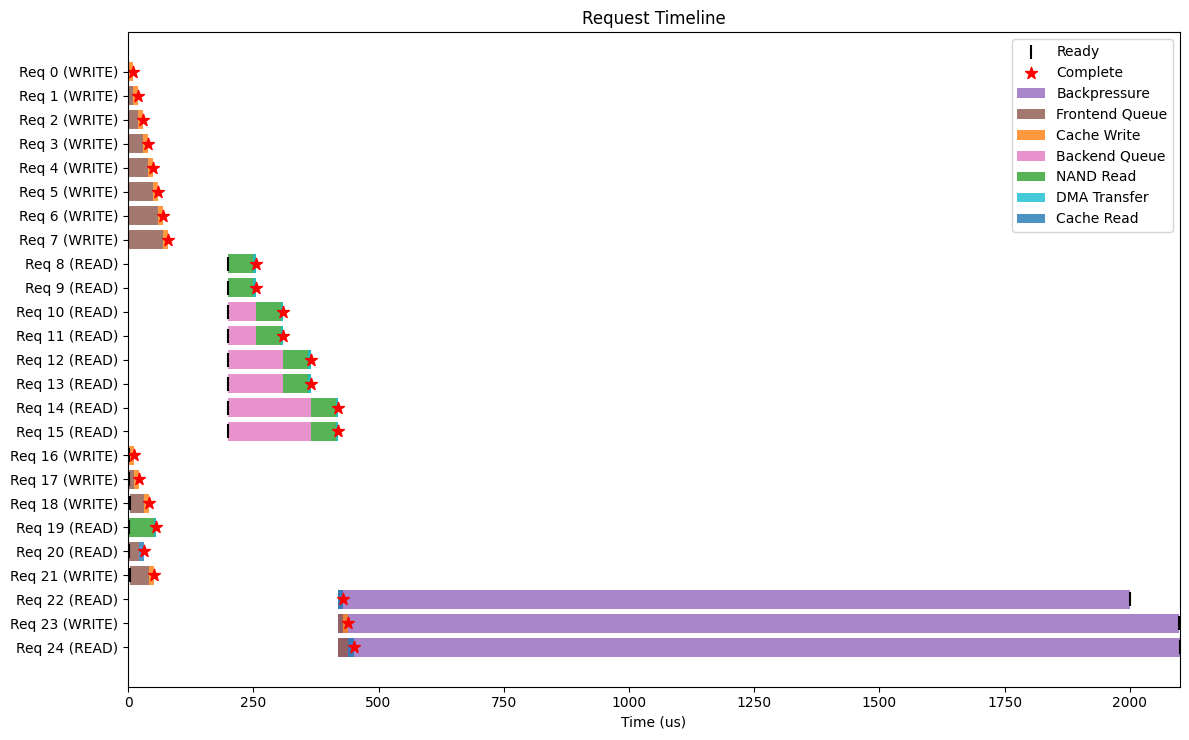

In [2]:
from request import TraceEvent
import matplotlib.pyplot as plt

sorted_requests = sorted(ssd.completed_requests, key=lambda r: r.id)

fig, ax = plt.subplots(figsize=(12, len(sorted_requests) * 0.3))

trace_sections = [
    ("Backpressure", TraceEvent.READY, TraceEvent.NCQ_QUEUED, "#9467bd"),
    ("Frontend Queue", TraceEvent.NCQ_QUEUED, TraceEvent.NCQ_DISPATCHED, "#8c564b"),
    (
        "Backend Queue",
        TraceEvent.BACKEND_QUEUED,
        TraceEvent.BACKEND_DISPATCHED,
        "#e377c2",
    ),
    (
        "Cache Read",
        TraceEvent.CACHE_READ_START,
        TraceEvent.CACHE_READ_COMPLETE,
        "#1f77b4",
    ),
    (
        "Cache Write",
        TraceEvent.CACHE_WRITE_START,
        TraceEvent.CACHE_WRITE_COMPLETE,
        "#ff7f0e",
    ),
    ("NAND Read", TraceEvent.NAND_READ_START, TraceEvent.NAND_READ_COMPLETE, "#2ca02c"),
    (
        "NAND Write",
        TraceEvent.NAND_WRITE_START,
        TraceEvent.NAND_WRITE_COMPLETE,
        "#d62728",
    ),
    ("DMA Transfer", TraceEvent.DMA_START, TraceEvent.DMA_COMPLETE, "#17becf"),
]

for i, req in enumerate(sorted_requests):
    trace = req.trace
    for section_name, start_event, end_event, color in trace_sections:
        if start_event in trace and end_event in trace:
            start_time = trace[start_event]
            end_time = trace[end_event]
            ax.barh(
                i,
                left=start_time,
                width=end_time - start_time,
                height=0.8,
                color=color,
                label=section_name,
                alpha=0.8,
            )
    # Mark READY and NCQ_COMPLETE events if present
    if TraceEvent.READY in trace:
        ax.scatter(
            trace[TraceEvent.READY],
            i,
            color="black",
            marker="|",
            s=100,
            label="Ready",
        )
    if TraceEvent.NCQ_COMPLETE in trace:
        ax.scatter(
            trace[TraceEvent.NCQ_COMPLETE],
            i,
            color="red",
            marker="*",
            s=80,
            label="Complete",
        )

ax.invert_yaxis()
ax.set_yticks(range(len(sorted_requests)))
ax.set_yticklabels([f"Req {req.id} ({req.type.name})" for req in sorted_requests])

ax.set_xlabel("Time (us)")
ax.set_title("Request Timeline")

# Remove duplicate labels and create legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right")

plt.tight_layout()
plt.show()

In [3]:
sorted_requests[8].trace

{<TraceEvent.READY: 1>: 200,
 <TraceEvent.NCQ_QUEUED: 2>: 200,
 <TraceEvent.NCQ_DISPATCHED: 3>: 200,
 <TraceEvent.BACKEND_QUEUED: 5>: 200,
 <TraceEvent.BACKEND_DISPATCHED: 6>: 200,
 <TraceEvent.NAND_READ_START: 11>: 200,
 <TraceEvent.DMA_QUEUED: 15>: 250,
 <TraceEvent.DMA_START: 16>: 250,
 <TraceEvent.DMA_COMPLETE: 17>: 255,
 <TraceEvent.NAND_READ_COMPLETE: 12>: 255,
 <TraceEvent.NCQ_COMPLETE: 4>: 255}